In [2]:
import numpy as np
%matplotlib inline

from devito import configuration
configuration['log-level'] = 'WARNING'

In [28]:
import segyio
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import gaussian_filter
from scipy.signal import correlate, convolve
from copy import deepcopy
from Function.util_additional import analisis_spektrum_source, dominant_frequency, plot_shot_gather, plot_all_shots, plot_wavefield_overlay, create_video_from_images
import os

In [4]:
vp = np.loadtxt('Model/Marmousi-12_5.txt')

print("Shape:", vp.shape)             # Dimensi (baris, kolom)
print("Tipe data:", vp.dtype)         # Tipe elemen
print("Mean:", np.mean(vp))           # Rata-rata seluruh elemen
print("Median:", np.median(vp))       # Median
print("Standard deviation:", np.std(vp))  # Standar deviasi
print("Min:", np.min(vp))
print("Max:", np.max(vp))
print("Sum:", np.sum(vp))

Shape: (1317, 281)
Tipe data: float64
Mean: 2.703933759460869
Median: 2.5118
Standard deviation: 0.9902387663233377
Min: 1.028
Max: 4.7
Sum: 1000663.6939000001


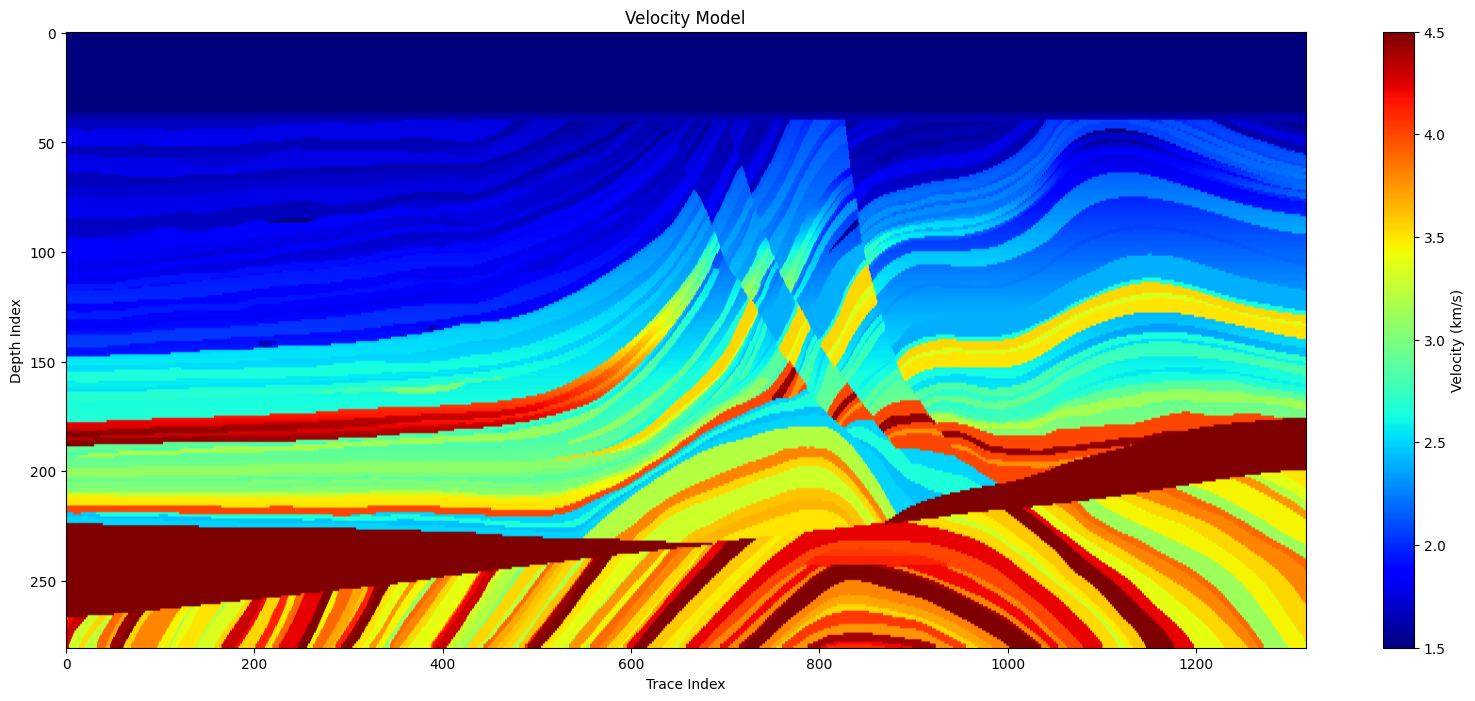

In [5]:
plt.figure(figsize=(20,8))
plt.imshow(vp.T, cmap='jet', aspect='auto', origin='upper', vmin=1.5, vmax=4.5)
plt.colorbar(label='Velocity (km/s)')
plt.title('Velocity Model')
plt.xlabel('Trace Index')
plt.ylabel('Depth Index')
plt.show()

In [6]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import Model, plot_velocity, plot_perturbation, Receiver



# Define a physical size
shape = (vp.shape)  # Number of grid point (nx, nz)
spacing = (12.5, 12.5)  # Grid spacing in m. The domain size is now 1km by 1km
origin = (0.,0.)  # What is the location of the top left corner. This is necessary to define
nboundary = 160


model = Model(vp=vp, origin=origin, shape=shape, spacing=spacing,
              space_order=2, nbl=nboundary, bcs="damp")

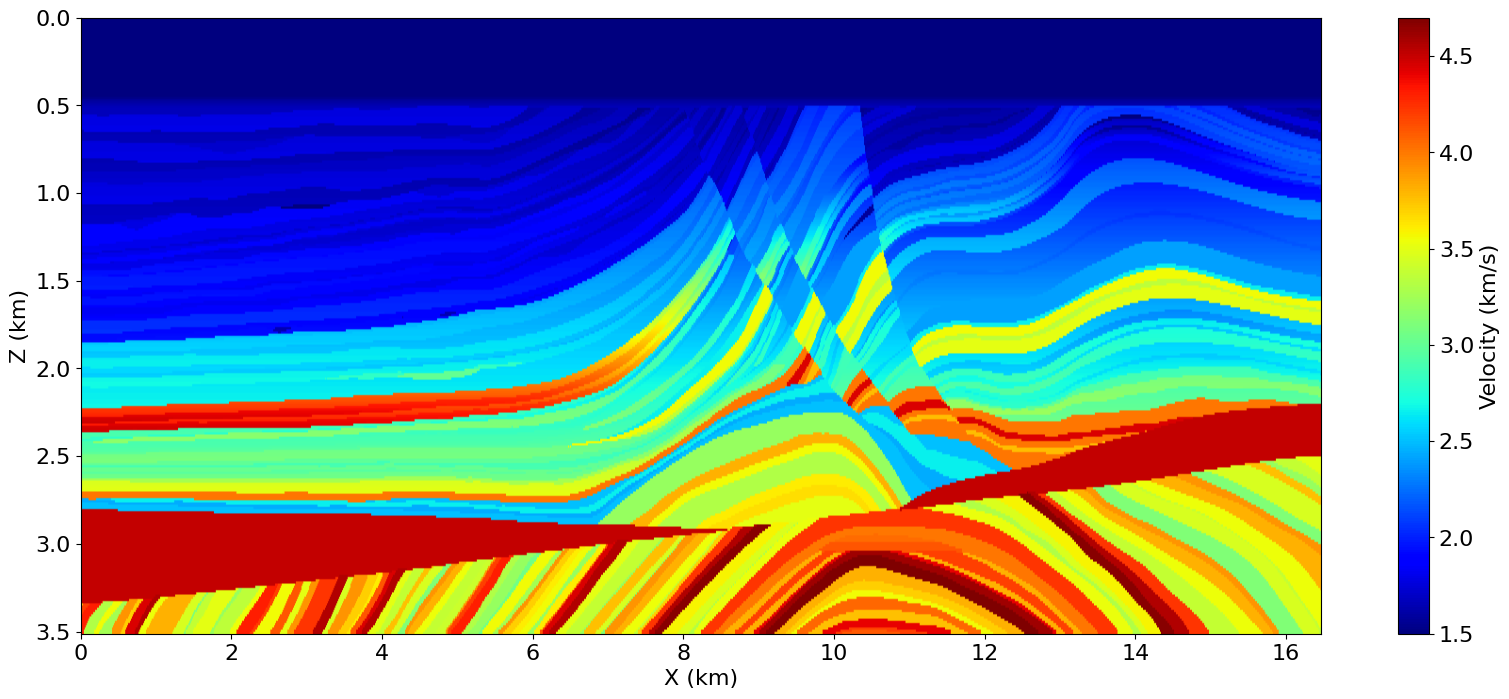

In [7]:
xmin = (origin[0]*spacing[0])/1000
zmin = (origin[1]*spacing[1])/1000
xmax = (origin[0]*spacing[0] + shape[0]*spacing[0])/1000
zmax = (origin[1]*spacing[1] + shape[1]*spacing[1])/1000
plt.figure(figsize=[20,8])
plt.imshow(model.vp.data[nboundary:nboundary+shape[0], nboundary:nboundary+shape[1]].T, extent=[xmin, xmax, zmax, zmin], cmap='jet', vmin=1.5, vmax=4.7, aspect='auto')
plt.colorbar(label="Velocity (km/s)")
plt.xlabel("X (km)")
plt.ylabel("Z (km)")
plt.show()

In [8]:
#NBVAL_IGNORE_OUTPUT
# Define acquisition geometry: source
from examples.seismic import AcquisitionGeometry, TimeAxis, RickerSource

#geometry define
#source geometry
nshots = 125  # Number of shots to create gradient from
shot_first_coordinate = 4050
shot_last_coordinate = 16450
shot_depth = 0

#receriver geometry
nreceivers = 160  # Number of receiver locations per shot 
first_channel_firstlreceriverline_coordinate = 75
last_channel_firstreceiverline_coordinate = 4050
receiverline_interval = 100
receiver_depth = 0


#recording define
dt = model.critical_dt
t0 = 0.
tn = 4504.
timeAx = TimeAxis(start=t0, stop=tn, step=dt)


#source define
f0 = 0.008
shift_phase = 0

In [9]:
# First, position source centrally in all dimensions, then set depth
def geometry_and_source(nshots, shot_first_coordinate, shot_last_coordinate, shot_depth, nreceivers, first_channel_firstlreceriverline_coordinate, last_channel_firstreceiverline_coordinate, receiver_depth, receiverline_interval, t0, tn, dt, f0, shift_phase):
    src_coordinates = np.empty((nshots, 2))
    src_coordinates[:, 0] = np.linspace(shot_first_coordinate, shot_last_coordinate, nshots)
    src_coordinates[:, 1] = shot_depth  # Depth is 20m

    geometrys = []

    for i in range(nshots):
        # Define acquisition geometry: receivers

        # Initialize receivers for synthetic and imaging data
        rec_coordinates = np.empty((nreceivers, 2))
        rec_coordinates[:, 0] = np.linspace(first_channel_firstlreceriverline_coordinate+(i*receiverline_interval), last_channel_firstreceiverline_coordinate+(i*receiverline_interval), nreceivers)
        rec_coordinates[:, 1] = receiver_depth  # Depth is 20m

        # Geometry
        geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker', dt=dt)
        geometrys.append(geometry)


    t = np.arange(t0, tn+dt, (dt))
    t = t/1000
    f0z = f0*1000
    t0 =   (1/f0z)
    st = (1 - (2*(np.pi**2)*(f0z**2)*(t-t0)**2))*(np.exp(-1*(np.pi**2)*(f0z**2)*(t-t0)**2))

    wavelet = st

    angle = shift_phase
    shifted = np.real(np.exp(1j*np.radians(angle)) * signal.hilbert(wavelet))
    shifted = np.array([shifted])
    shiftedT = shifted.T

    srcs = []

    for i in range(nshots):
        src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=timeAx)
        # First, position source centrally in all dimensions, then set depth
        src.coordinates.data[0, :] = src_coordinates[i, 0]
        src.coordinates.data[0, -1] = shot_depth  # Depth is 20m
        src.data[:] = shiftedT
        srcs.append(src)

    return geometrys, srcs

In [10]:
geometrys, srcs = geometry_and_source(nshots, shot_first_coordinate, shot_last_coordinate, shot_depth, nreceivers, first_channel_firstlreceriverline_coordinate, last_channel_firstreceiverline_coordinate, receiver_depth, receiverline_interval, t0, tn, dt, f0, shift_phase)

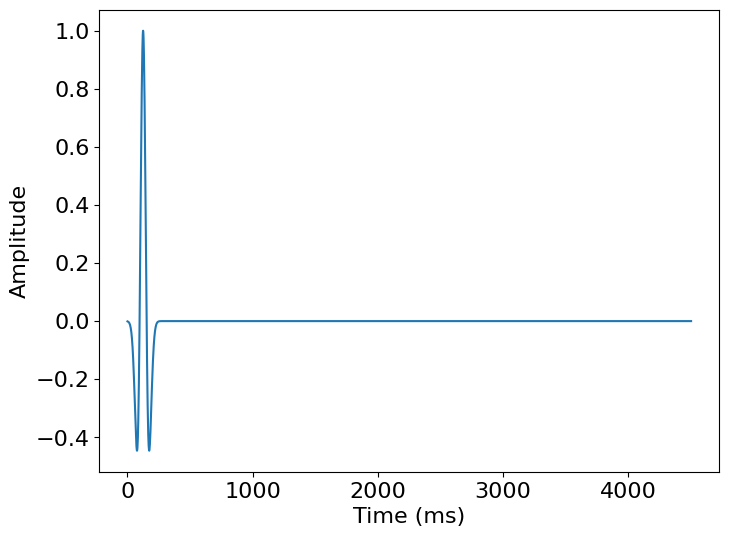

(2766, 1)
TimeAxis: start=0, stop=4504.19, step=1.629, num=2766
1.629


In [11]:
srcs[0].show()
print(srcs[0].data.shape)

print(geometrys[0])
print(geometrys[0].time_axis)
print(dt)

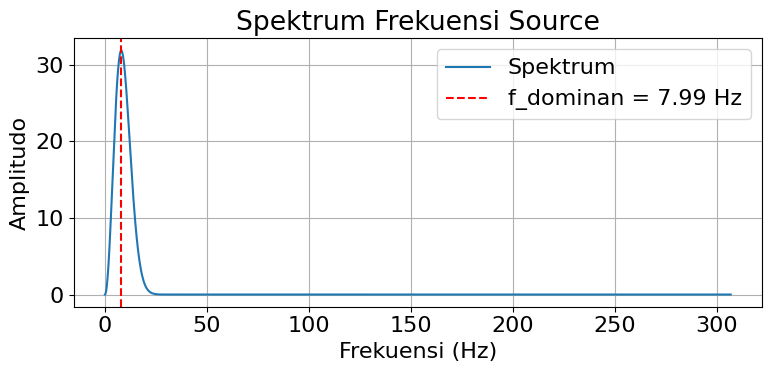

Frekuensi dominan: 7.99 Hz


In [12]:
f_dom = analisis_spektrum_source(srcs[0].data, dt=(dt/1000))
print(f"Frekuensi dominan: {f_dom:.2f} Hz")

In [13]:
recs_coordinate = []

for i in range(nshots):
    recs_coordinate.append(geometrys[i].rec_positions)

recs_coordinate = np.array(recs_coordinate)


print(recs_coordinate.shape)
print(recs_coordinate[0])

(125, 160, 2)
[[  75.    0.]
 [ 100.    0.]
 [ 125.    0.]
 [ 150.    0.]
 [ 175.    0.]
 [ 200.    0.]
 [ 225.    0.]
 [ 250.    0.]
 [ 275.    0.]
 [ 300.    0.]
 [ 325.    0.]
 [ 350.    0.]
 [ 375.    0.]
 [ 400.    0.]
 [ 425.    0.]
 [ 450.    0.]
 [ 475.    0.]
 [ 500.    0.]
 [ 525.    0.]
 [ 550.    0.]
 [ 575.    0.]
 [ 600.    0.]
 [ 625.    0.]
 [ 650.    0.]
 [ 675.    0.]
 [ 700.    0.]
 [ 725.    0.]
 [ 750.    0.]
 [ 775.    0.]
 [ 800.    0.]
 [ 825.    0.]
 [ 850.    0.]
 [ 875.    0.]
 [ 900.    0.]
 [ 925.    0.]
 [ 950.    0.]
 [ 975.    0.]
 [1000.    0.]
 [1025.    0.]
 [1050.    0.]
 [1075.    0.]
 [1100.    0.]
 [1125.    0.]
 [1150.    0.]
 [1175.    0.]
 [1200.    0.]
 [1225.    0.]
 [1250.    0.]
 [1275.    0.]
 [1300.    0.]
 [1325.    0.]
 [1350.    0.]
 [1375.    0.]
 [1400.    0.]
 [1425.    0.]
 [1450.    0.]
 [1475.    0.]
 [1500.    0.]
 [1525.    0.]
 [1550.    0.]
 [1575.    0.]
 [1600.    0.]
 [1625.    0.]
 [1650.    0.]
 [1675.    0.]
 [1700.    

In [14]:
srcs_coordinate = np.array(geometrys[0].src_positions)


print(srcs_coordinate.shape)
print(srcs_coordinate)


(125, 2)
[[ 4050.     0.]
 [ 4150.     0.]
 [ 4250.     0.]
 [ 4350.     0.]
 [ 4450.     0.]
 [ 4550.     0.]
 [ 4650.     0.]
 [ 4750.     0.]
 [ 4850.     0.]
 [ 4950.     0.]
 [ 5050.     0.]
 [ 5150.     0.]
 [ 5250.     0.]
 [ 5350.     0.]
 [ 5450.     0.]
 [ 5550.     0.]
 [ 5650.     0.]
 [ 5750.     0.]
 [ 5850.     0.]
 [ 5950.     0.]
 [ 6050.     0.]
 [ 6150.     0.]
 [ 6250.     0.]
 [ 6350.     0.]
 [ 6450.     0.]
 [ 6550.     0.]
 [ 6650.     0.]
 [ 6750.     0.]
 [ 6850.     0.]
 [ 6950.     0.]
 [ 7050.     0.]
 [ 7150.     0.]
 [ 7250.     0.]
 [ 7350.     0.]
 [ 7450.     0.]
 [ 7550.     0.]
 [ 7650.     0.]
 [ 7750.     0.]
 [ 7850.     0.]
 [ 7950.     0.]
 [ 8050.     0.]
 [ 8150.     0.]
 [ 8250.     0.]
 [ 8350.     0.]
 [ 8450.     0.]
 [ 8550.     0.]
 [ 8650.     0.]
 [ 8750.     0.]
 [ 8850.     0.]
 [ 8950.     0.]
 [ 9050.     0.]
 [ 9150.     0.]
 [ 9250.     0.]
 [ 9350.     0.]
 [ 9450.     0.]
 [ 9550.     0.]
 [ 9650.     0.]
 [ 9750.     0.]
 [ 98

In [15]:
recs_x = recs_coordinate[:,:,0]
recs_y = recs_coordinate[:,:,1]

print(recs_x[0])
print(recs_y[0])
print(srcs_coordinate[0])

[  75.  100.  125.  150.  175.  200.  225.  250.  275.  300.  325.  350.
  375.  400.  425.  450.  475.  500.  525.  550.  575.  600.  625.  650.
  675.  700.  725.  750.  775.  800.  825.  850.  875.  900.  925.  950.
  975. 1000. 1025. 1050. 1075. 1100. 1125. 1150. 1175. 1200. 1225. 1250.
 1275. 1300. 1325. 1350. 1375. 1400. 1425. 1450. 1475. 1500. 1525. 1550.
 1575. 1600. 1625. 1650. 1675. 1700. 1725. 1750. 1775. 1800. 1825. 1850.
 1875. 1900. 1925. 1950. 1975. 2000. 2025. 2050. 2075. 2100. 2125. 2150.
 2175. 2200. 2225. 2250. 2275. 2300. 2325. 2350. 2375. 2400. 2425. 2450.
 2475. 2500. 2525. 2550. 2575. 2600. 2625. 2650. 2675. 2700. 2725. 2750.
 2775. 2800. 2825. 2850. 2875. 2900. 2925. 2950. 2975. 3000. 3025. 3050.
 3075. 3100. 3125. 3150. 3175. 3200. 3225. 3250. 3275. 3300. 3325. 3350.
 3375. 3400. 3425. 3450. 3475. 3500. 3525. 3550. 3575. 3600. 3625. 3650.
 3675. 3700. 3725. 3750. 3775. 3800. 3825. 3850. 3875. 3900. 3925. 3950.
 3975. 4000. 4025. 4050.]
[0. 0. 0. 0. 0. 0. 0. 0. 

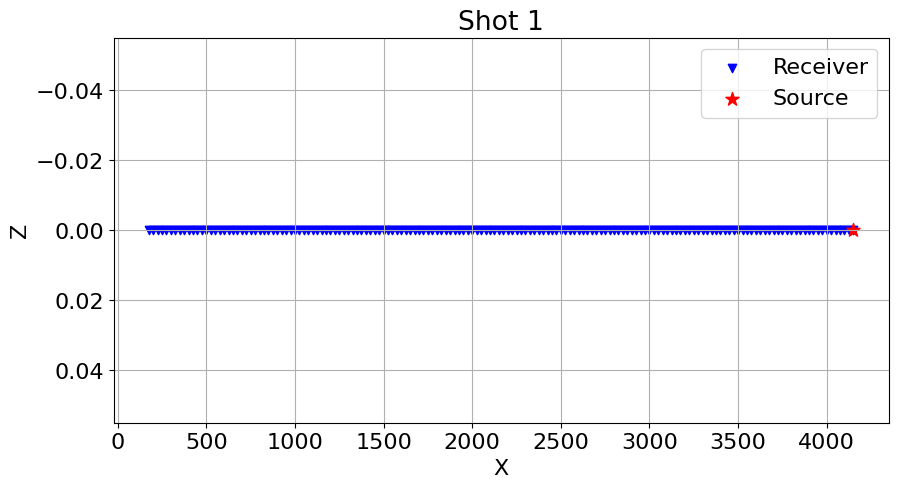

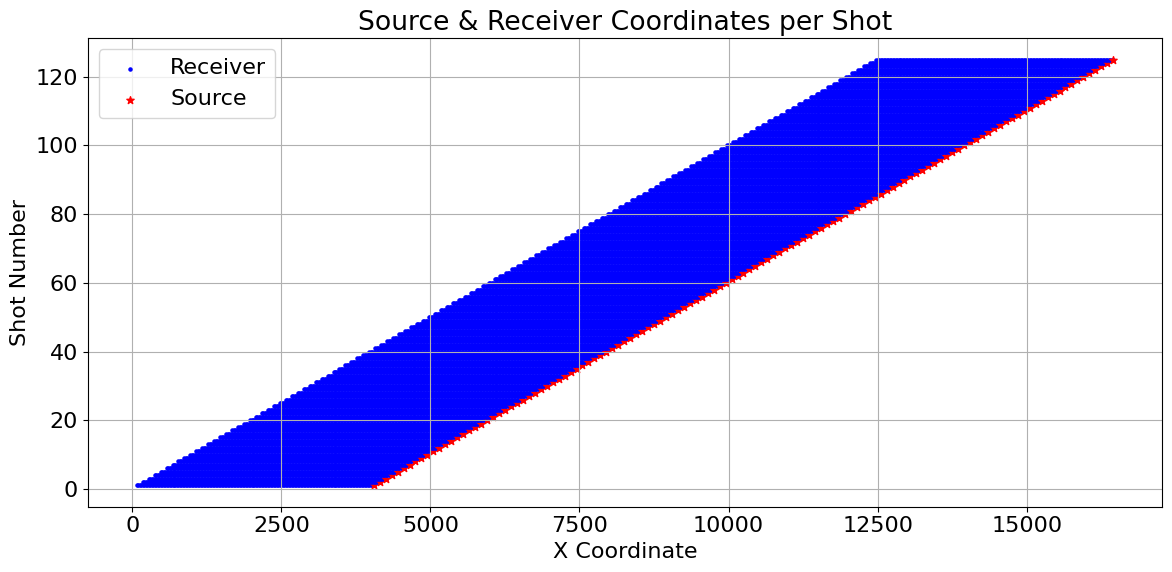

In [16]:
plot_shot_gather(recs_coordinate, srcs_coordinate, 1)
plot_all_shots(recs_coordinate, srcs_coordinate)

In [17]:
data_obs = []

n_shot = 62
for i in range(1):
        i=n_shot
        # Compute synthetic data with forward operator
        from examples.seismic.acoustic import AcousticWaveSolver

        solver = AcousticWaveSolver(model, geometrys[i], space_order=2)

        d_obs = Receiver(name='d_obs', grid=model.grid,
                         time_range=geometrys[i].time_axis,
                         coordinates=geometrys[i].rec_positions)
        # Update source location
        #geometry.src_positions[0, :] = src_coordinates[i, :]

        # Generate synthetic data from true model
        _, u0, _ = solver.forward(model=model, src=srcs[i], rec=d_obs, save=True)

        data_obs.append(np.array(d_obs.data[:]))
        
        print(f"Shots {i+1} selesai")

data_obs = np.array(data_obs)

Shots 63 selesai


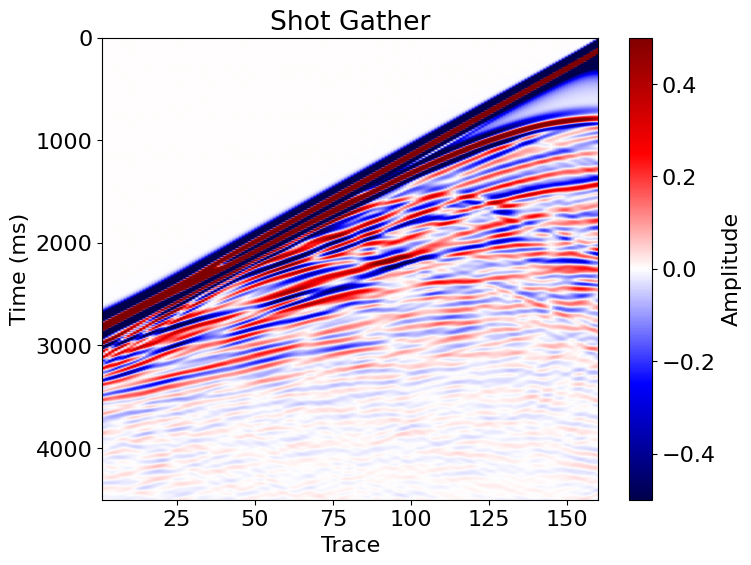

In [18]:
plt.figure
plt.imshow(data_obs[0], aspect='auto', cmap='seismic', extent=[1, 160, 4504, 0], vmax=0.5, vmin=-0.5)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Shot Gather')
plt.colorbar(label='Amplitude')
plt.show()

In [19]:
u0.shape

(2766, 1637, 601)

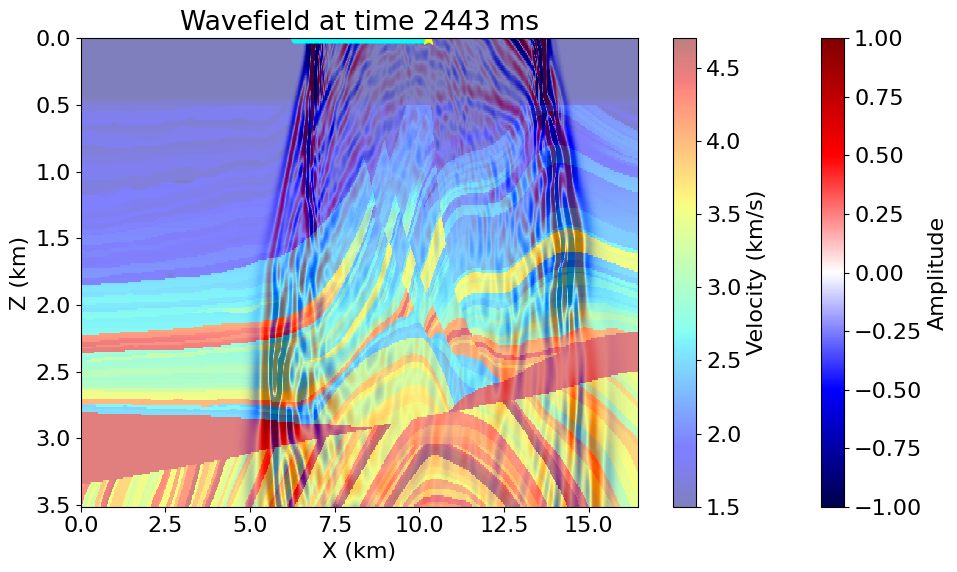

In [20]:
plot_wavefield_overlay(velocity=model, wavefield=u0, dt=dt, time_step=int(1500), origin=origin, spacing=spacing, shape=shape, nboundary=nboundary, shot_coordinate=srcs_coordinate[n_shot], receiver_coordinate=recs_coordinate[n_shot], show=True, cmap_wave='seismic', alpha=0.5, SeisAmpMin=-1, SeisAmpMax=1)

In [24]:
tipe_wavefield = "Forward"
frekuensi_wavefield = "8"
clear = True

image_folder = f"SEGY Creation/Snapshot/Shot {n_shot+1}"
output_video = f"SEGY Creation/Snapshot/Shot {n_shot+1}/Forward {n_shot+1}.mp4"


if (clear) :
    for filename in os.listdir(image_folder):
        file_path = os.path.join(image_folder, filename)

        if os.path.isfile(file_path):
            os.remove(file_path)

    print("All files deleted.")


shot = [0, 62, 124]
shot_loc = 62
nt_end = u0.shape[0]-1
n_frame = 100
int_frame = int(nt_end/n_frame)

for i in range(n_frame):
    plot_wavefield_overlay(velocity=model, wavefield=u0, dt=dt, time_step=int(int_frame*i), origin=origin, spacing=spacing, shape=shape, nboundary=nboundary, shot_coordinate=srcs_coordinate[shot_loc], receiver_coordinate=recs_coordinate[shot_loc], show=False, cmap_wave='seismic', alpha=0.5, save=True, path=image_folder, SeisAmpMin=-1, SeisAmpMax=1)

All files deleted.


In [29]:
create_video_from_images(image_folder, output_video, 5)

Mulai membuat video dari 100 gambar...


ffmpeg version n4.3.1 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7 (Ubuntu 7.5.0-3ubuntu1~18.04)
  configuration: --prefix= --prefix=/usr --disable-debug --disable-doc --disable-static --enable-cuda --enable-cuda-sdk --enable-cuvid --enable-libdrm --enable-ffplay --enable-gnutls --enable-gpl --enable-libass --enable-libfdk-aac --enable-libfontconfig --enable-libfreetype --enable-libmp3lame --enable-libnpp --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopus --enable-libpulse --enable-sdl2 --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libv4l2 --enable-libvorbis --enable-libvpx --enable-libx264 --enable-libx265 --enable-libxcb --enable-libxvid --enable-nonfree --enable-nvenc --enable-omx --enable-openal --enable-opencl --enable-runtime-cpudetect --enable-shared --enable-vaapi --enable-vdpau --enable-version3 --enable-xlib
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 

Video berhasil dibuat di: SEGY Creation/Snapshot/Shot 63/Forward 63.mp4


In [30]:
from IPython.display import Video

Video(output_video, embed=True)

In [31]:
data_obs = []

for i in range(nshots):
        # Compute synthetic data with forward operator
        from examples.seismic.acoustic import AcousticWaveSolver

        solver = AcousticWaveSolver(model, geometrys[i], space_order=2)

        d_obs = Receiver(name='d_obs', grid=model.grid,
                         time_range=geometrys[i].time_axis,
                         coordinates=geometrys[i].rec_positions)
        # Update source location
        #geometry.src_positions[0, :] = src_coordinates[i, :]

        # Generate synthetic data from true model
        _, _, _ = solver.forward(model=model, src=srcs[i], rec=d_obs)

        data_obs.append(np.array(d_obs.data[:]))
        
        print(f"Shots {i+1} selesai")

data_obs = np.array(data_obs)

Shots 1 selesai
Shots 2 selesai
Shots 3 selesai
Shots 4 selesai
Shots 5 selesai
Shots 6 selesai
Shots 7 selesai
Shots 8 selesai
Shots 9 selesai
Shots 10 selesai
Shots 11 selesai
Shots 12 selesai
Shots 13 selesai
Shots 14 selesai
Shots 15 selesai
Shots 16 selesai
Shots 17 selesai
Shots 18 selesai
Shots 19 selesai
Shots 20 selesai
Shots 21 selesai
Shots 22 selesai
Shots 23 selesai
Shots 24 selesai
Shots 25 selesai
Shots 26 selesai
Shots 27 selesai
Shots 28 selesai
Shots 29 selesai
Shots 30 selesai
Shots 31 selesai
Shots 32 selesai
Shots 33 selesai
Shots 34 selesai
Shots 35 selesai
Shots 36 selesai
Shots 37 selesai
Shots 38 selesai
Shots 39 selesai
Shots 40 selesai
Shots 41 selesai
Shots 42 selesai
Shots 43 selesai
Shots 44 selesai
Shots 45 selesai
Shots 46 selesai
Shots 47 selesai
Shots 48 selesai
Shots 49 selesai
Shots 50 selesai
Shots 51 selesai
Shots 52 selesai
Shots 53 selesai
Shots 54 selesai
Shots 55 selesai
Shots 56 selesai
Shots 57 selesai
Shots 58 selesai
Shots 59 selesai
Shots 

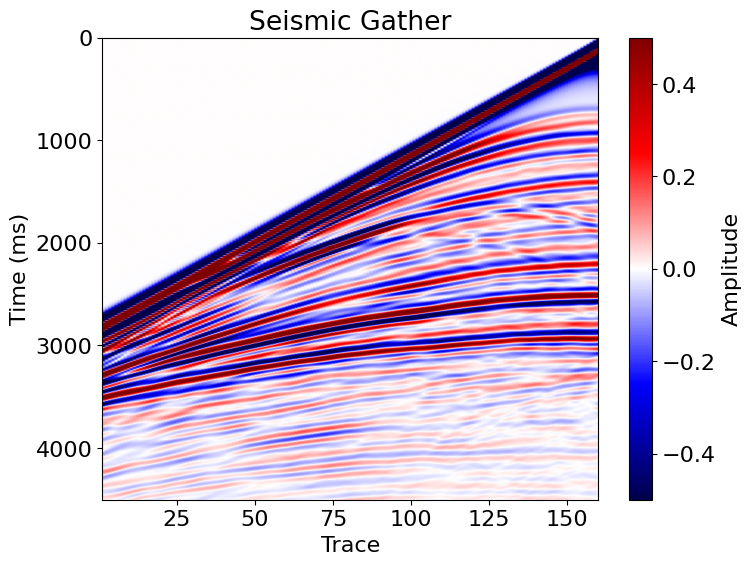

In [32]:
plt.figure()
plt.imshow(data_obs[0], aspect='auto', cmap='seismic', extent=[1, 160, 4504, 0], vmax=0.5, vmin=-0.5)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Gather')
plt.colorbar(label='Amplitude')
plt.show()

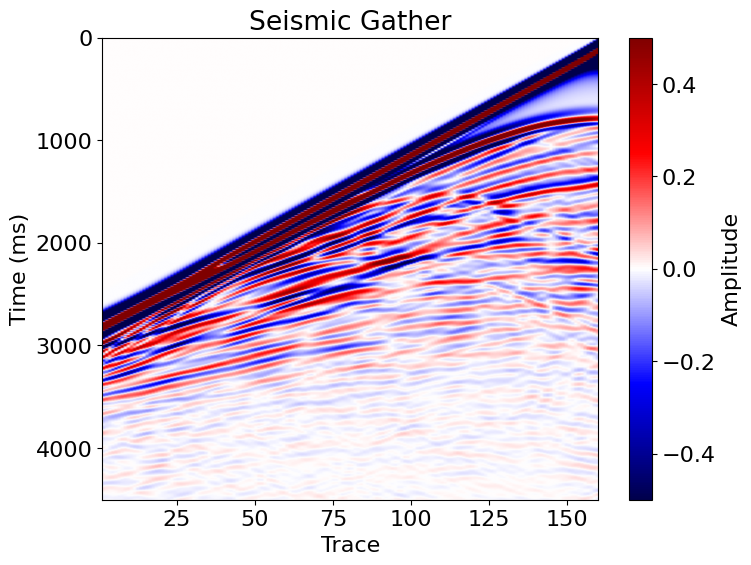

In [33]:
plt.figure()
plt.imshow(data_obs[62], aspect='auto', cmap='seismic', extent=[1, 160, 4504, 0], vmax=0.5, vmin=-0.5)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Gather')
plt.colorbar(label='Amplitude')
plt.show()

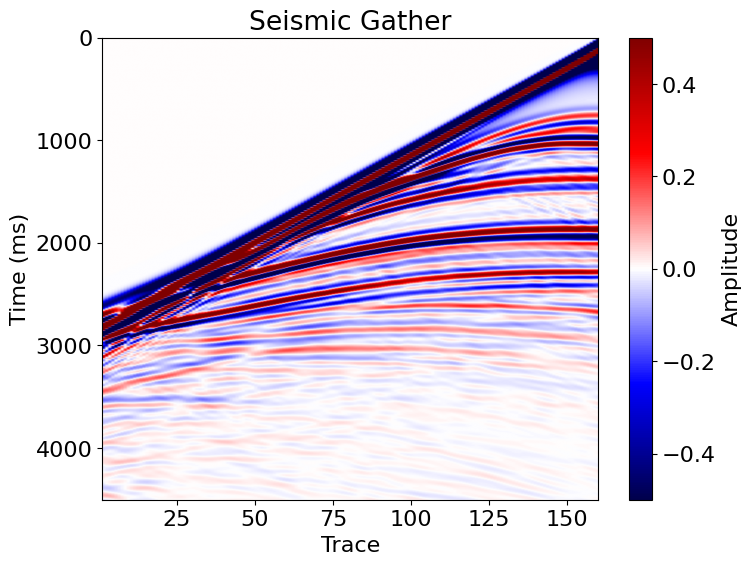

In [34]:
plt.figure()
plt.imshow(data_obs[124], aspect='auto', cmap='seismic', extent=[1, 160, 4504, 0], vmax=0.5, vmin=-0.5)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Seismic Gather')
plt.colorbar(label='Amplitude')
plt.show()

In [35]:
from copy import deepcopy

np.save(f'SEGY Creation/Seismic Data/NPY Marmousi 12-5.npy', data_obs)

In [36]:
from copy import deepcopy
import numpy as np
import segyio
import os


data_obs = np.load('SEGY Creation/Seismic Data/NPY Marmousi 12-5.npy')

In [37]:
# Buat output file

nsamples = 2766
dt = 1.629
dt_us = dt*1000


n_receiver_x = recs_x
receiver_y = np.zeros(nreceivers)
receiver_z = 0


output_file = "SEGY Creation/Seismic Data/SEGY Marmousi 12-5.sgy"

# Pastikan file tidak eksis dulu
if os.path.exists(output_file):
    os.remove(output_file)

# Konfigurasi file segyio
spec = segyio.spec()
spec.sorting = 1  # shot ordered
spec.format = 5   # IEEE float
spec.samples = np.arange(0, nsamples * dt, dt)
spec.tracecount = nshots * nreceivers

with segyio.create(output_file, spec) as f:
    trace_index = 0
    for j in range(nshots):
        for i in range(nreceivers):
            trace_data = data_obs[j, :, i].astype(np.float32)
            f.trace[trace_index] = trace_data

            # Set header trace
            f.header[trace_index] = {
                segyio.TraceField.TRACE_SEQUENCE_LINE: int(trace_index + 1),
                segyio.TraceField.TRACE_SEQUENCE_FILE: int(trace_index + 1),
                segyio.TraceField.FieldRecord: int(j + 1),  # FFID
                segyio.TraceField.TraceNumber: int(i + 1),
                segyio.TraceField.EnergySourcePoint : int(j+1),
                segyio.TraceField.CDP: int((i+1) + (8*j)),
                segyio.TraceField.CDP_TRACE : int(trace_index + 1),
                segyio.TraceField.TraceIdentificationCode : int(1),
                segyio.TraceField.DataUse : int(1),
                segyio.TraceField.offset: int(n_receiver_x[j][i]-srcs_coordinate[j, 0]),
                segyio.TraceField.ReceiverGroupElevation: int(receiver_z),
                segyio.TraceField.SourceSurfaceElevation: int(0),
                segyio.TraceField.SourceDepth: int(0),
                segyio.TraceField.ReceiverDatumElevation: int(0),
                segyio.TraceField.SourceDatumElevation: int(0),
                segyio.TraceField.SourceX: int(srcs_coordinate[j, 0]),
                segyio.TraceField.SourceY: int(srcs_coordinate[j, 1]),
                segyio.TraceField.GroupX: int(n_receiver_x[j][i]),
                segyio.TraceField.GroupY: int(receiver_y[i]),
                segyio.TraceField.CoordinateUnits: int(1),
                segyio.TraceField.TRACE_SAMPLE_COUNT : nsamples,
                segyio.TraceField.TRACE_SAMPLE_INTERVAL : int(dt*1000),
                segyio.TraceField.CDP_X : int(((i+1) + (8*j) + 164)*12.5*1000),
                segyio.TraceField.CDP_Y : 0,
                segyio.TraceField.INLINE_3D : int(i + 1),
                segyio.TraceField.CROSSLINE_3D : int(trace_index + 1)
            }

            trace_index += 1

print(f"✅ File SEG-Y berhasil dibuat: {output_file}")


✅ File SEG-Y berhasil dibuat: SEGY Creation/Seismic Data/SEGY Marmousi 12-5.sgy


In [38]:
import segyio
import numpy as np
from collections import defaultdict

filename = 'SEGY Creation/Seismic Data/SEGY Marmousi 12-5.sgy'

# Dictionary untuk menyimpan shot gathers
shot_data = defaultdict(list)

with segyio.open(filename, "r", ignore_geometry=True) as segyfile:
    segyfile.mmap()
    n_traces = segyfile.tracecount
    n_samples = segyfile.samples.size
    
    # Ambil ID field record (shot number) per trace
    shot_ids = segyfile.attributes(segyio.TraceField.FieldRecord)[:]
    
    # Kelompokkan trace per shot
    for i in range(n_traces):
        shot_id = shot_ids[i]
        trace = segyfile.trace[i]
        shot_data[shot_id].append(trace)

# Ubah list trace per shot menjadi array (samples x trace)
shot_gathers = []
for shot_id, traces in shot_data.items():
    gather = np.stack(traces).T  # shape: (samples, traces)
    shot_gathers.append(gather)

# Contoh: akses shot ke-0
first_shot = shot_gathers[0]
print("Shape of first shot:", first_shot.shape)


Shape of first shot: (2766, 160)


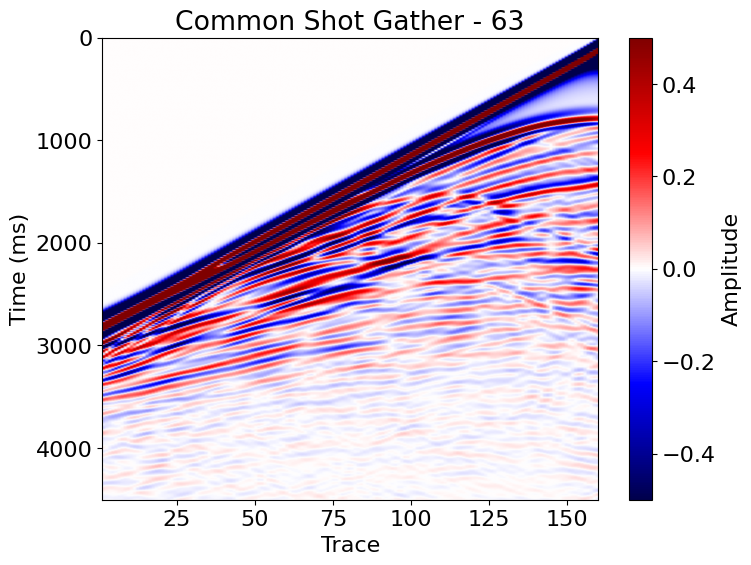

In [39]:
plt.imshow(shot_gathers[62], aspect='auto', cmap='seismic', extent=[1, 160, 4504, 0], vmax=0.5, vmin=-0.5)
plt.xlabel('Trace')
plt.ylabel('Time (ms)')
plt.title('Common Shot Gather - 63')
plt.colorbar(label='Amplitude')
plt.show()